# Green River Mammmoth Cave USGS Gauge Data (Site 03309000) Anlysis of flood events since removal of L&D6 (2018-2026)

In [ ]:
## Installing libraries
# Install as needed.

%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install requests

In [ ]:
# Import Libraries and print Versions
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import numpy as np
import os
import sys
import requests
import json





Download USGS Gauge Data for Green River Mammoth Cave

In [184]:
## USGS Gauge Data
url = 'https://nwis.waterservices.usgs.gov/nwis/iv/?sites=03309000&agencyCd=USGS&startDT=2018-01-01T00:00:00.000-06:00&endDT=2026-02-24T23:59:59.999-05:00&parameterCd=00065&format=rdb'

try: 
    response = requests.get(url)
    response.raise_for_status()  # Raise an error for bad responses
except requests.exceptions.RequestException as e:
    print(f"Error: {e}")
    # Handle the error appropriately (e.g., log it, retry, etc.)
    exit()

Read the data that is in CSV into a dataframe

In [185]:
from io import StringIO

# Parse the response content and convert it into a DataFrame

# Decode the response content
content = response.content.decode('utf-8')

# Skip comment lines (lines starting with '#') and create a DataFrame
data_lines = "\n".join([line for line in content.splitlines() if not line.startswith('#')])
df = pd.read_csv(StringIO(data_lines), sep='\t')

# Display the first few rows of the DataFrame
print(df.head())

  agency_cd   site_no          datetime tz_cd 220645_00065 220645_00065_cd
0        5s       15s               20d    6s          14n             10s
1      USGS  03309000  2018-01-01 00:00   CST        20.20               A
2      USGS  03309000  2018-01-01 00:15   CST        20.19               A
3      USGS  03309000  2018-01-01 00:30   CST        20.19               A
4      USGS  03309000  2018-01-01 00:45   CST        20.17               A


/var/folders/vj/vdrtmr891czclg0wttpr4h2h0000gn/T/ipykernel_11302/1245403309.py:10: DtypeWarning: Columns (1,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(StringIO(data_lines), sep='\t')


Convert data to date time and add new column that converts guage height to elevation

In [186]:
# Rename columns for clarity
df = df.rename(columns={"220645_00065_cd":"approved", "tz_cd":"timezone", "220645_00065":"gauge"})

# Remove the first row of the DataFrame
df = df.iloc[1:]

# Reset the index of the DataFrame
df = df.reset_index(drop=True)

# Convert the 'dateTime' column to datetime format
df['datetime'] = pd.to_datetime(df['datetime'])
df['month'] = df['datetime'].dt.month
df['day'] = df['datetime'].dt.day
df['year'] = df['datetime'].dt.year

# Create a new DataFrame with the desired columns       
df2 = df[['datetime', 'gauge', 'month', 'day', 'year']]

# Add 'height' column: gage + offset (use offset_ft defined in later cells)
offset_ft = 409.35
df2['elev'] = pd.to_numeric(df2['gauge'], errors='coerce') + offset_ft

# Display Data to check
df2.head()

/var/folders/vj/vdrtmr891czclg0wttpr4h2h0000gn/T/ipykernel_11302/2146477615.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['elev'] = pd.to_numeric(df2['gauge'], errors='coerce') + offset_ft


,datetime,gauge,month,day,year,elev
0,2018-01-01 00:00:00,20.20,1,1,2018,429.55
1,2018-01-01 00:15:00,20.19,1,1,2018,429.54
2,2018-01-01 00:30:00,20.19,1,1,2018,429.54
3,2018-01-01 00:45:00,20.17,1,1,2018,429.52
4,2018-01-01 01:00:00,20.15,1,1,2018,429.50


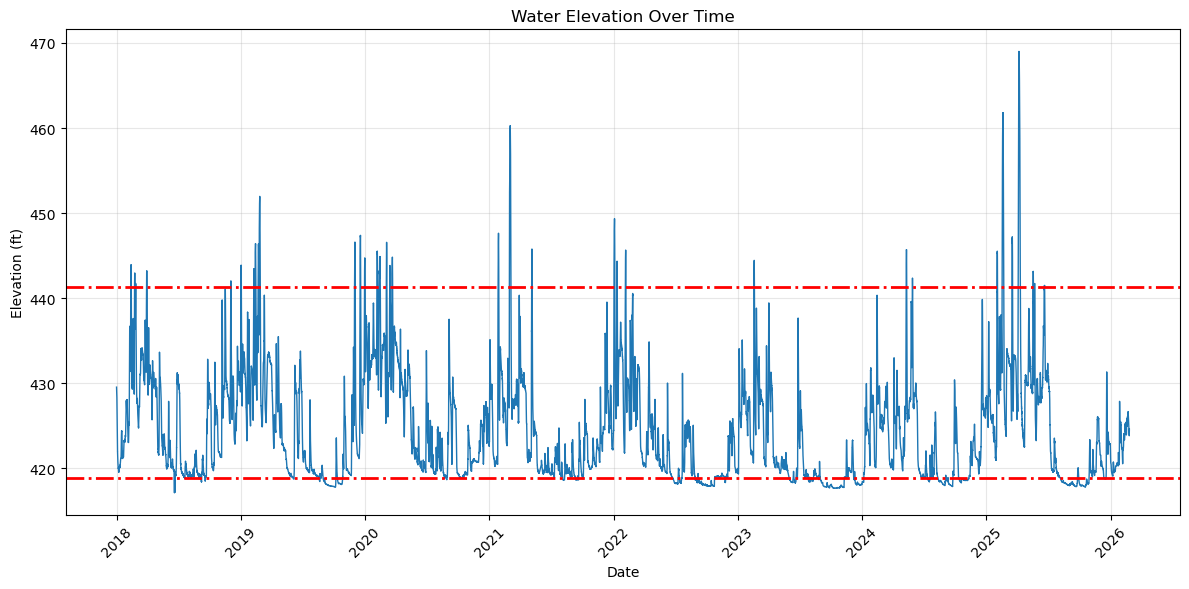

In [187]:
plt.figure(figsize=(12, 6))
plt.plot(df2['datetime'], df2['elev'], linewidth=1)
plt.title('Water Elevation Over Time')
plt.xlabel('Date')
plt.ylabel('Elevation (ft)')
low_water = 418.85
high_water = 441.35
plt.axhline(y=low_water, color='red', linestyle='-.', linewidth=2, label=f'9.5 ft ({low_water})')
plt.axhline(y=high_water, color='red', linestyle='-.', linewidth=2, label=f'32 ft ({high_water})')

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/var/folders/vj/vdrtmr891czclg0wttpr4h2h0000gn/T/ipykernel_11302/885463228.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['gauge'] = pd.to_numeric(df2['gauge'], errors='coerce')
/var/folders/vj/vdrtmr891czclg0wttpr4h2h0000gn/T/ipykernel_11302/885463228.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


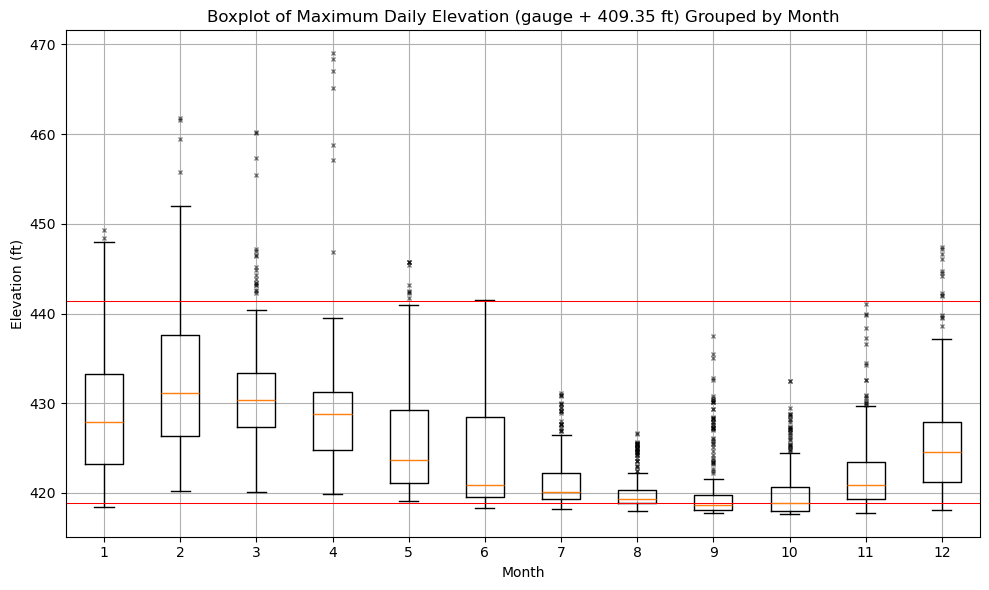

In [189]:
# Ensure the 'gauge' column in df is numeric
df['gauge'] = pd.to_numeric(df['gauge'], errors='coerce')

# Ensure the 'gauge' column in df2 is numeric
df2['gauge'] = pd.to_numeric(df2['gauge'], errors='coerce')

# Create a DataFrame of the maximum gauge value for each day
daily_max_df = df.groupby(df['datetime'].dt.date)['gauge'].max().reset_index()
daily_max_df.columns = ['date', 'max_daily_gauge']

# Add a month column to the daily_max_df
daily_max_df['month'] = pd.to_datetime(daily_max_df['date']).dt.month

# Apply vertical offset in feet (convert gage to elevation):
offset_ft = 409.35
daily_max_df['max_daily_elev_ft'] = daily_max_df['max_daily_gauge'] + offset_ft

# Group the maximum daily elevation by month
grouped_daily_max = daily_max_df.groupby('month')['max_daily_elev_ft']

# Create a boxplot of the maximum daily elevations grouped by month
plt.figure(figsize=(10, 6))
plt.boxplot(
    [group for _, group in grouped_daily_max],
    labels=grouped_daily_max.groups.keys(),
    flierprops={
        'marker': 'x',  # Outlier marker symbol
        'markerfacecolor': 'red',  # Outlier marker color
        'markeredgecolor': 'black',  # Outlier marker edge color
        'markersize': 3,  # Outlier marker size
        'alpha': 0.5  # Outlier opacity
    }
)
plt.title('Boxplot of Maximum Daily Elevation (gauge + 409.35 ft) Grouped by Month')
plt.xlabel('Month')
plt.ylabel('Elevation (ft)')
plt.grid(True)
low_water = 418.85
high_water = 441.35
plt.axhline(y=low_water, color='red', linestyle='-', linewidth=0.75, label=f'9.5 ft ({low_water})')
plt.axhline(y=high_water, color='red', linestyle='-', linewidth=0.75, label=f'32 ft ({high_water})')
plt.tight_layout()
plt.show()

Make a Box Plot of the Max Daily Guage Height for each month.

/var/folders/vj/vdrtmr891czclg0wttpr4h2h0000gn/T/ipykernel_11302/753772487.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['gauge'] = pd.to_numeric(df2['gauge'], errors='coerce')
/var/folders/vj/vdrtmr891czclg0wttpr4h2h0000gn/T/ipykernel_11302/753772487.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


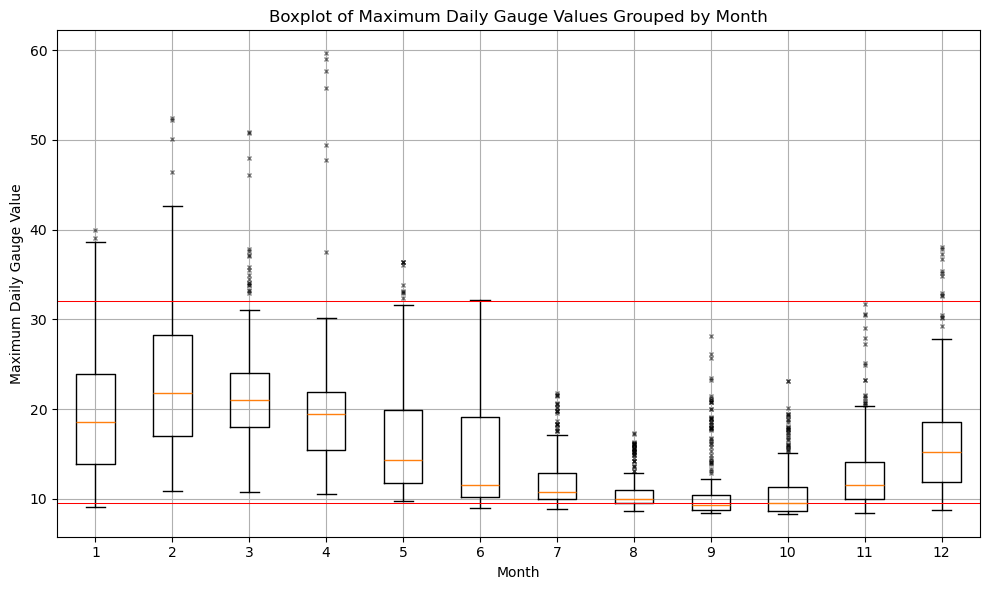

In [190]:
# Ensure the 'gauge' column in df is numeric
df['gauge'] = pd.to_numeric(df['gauge'], errors='coerce')

# Ensure the 'gauge' column in df2 is numeric
df2['gauge'] = pd.to_numeric(df2['gauge'], errors='coerce')

# Create a DataFrame of the maximum gauge value for each day
daily_max_df = df.groupby(df['datetime'].dt.date)['gauge'].max().reset_index()
daily_max_df.columns = ['date', 'max_daily_gauge']

# Add a month column to the daily_max_df
daily_max_df['month'] = pd.to_datetime(daily_max_df['date']).dt.month

# Group the maximum daily values by month
grouped_daily_max = daily_max_df.groupby('month')['max_daily_gauge']

# Create a boxplot of the maximum daily values grouped by month
plt.figure(figsize=(10, 6))
plt.boxplot(
    [group for _, group in grouped_daily_max],
    labels=grouped_daily_max.groups.keys(),
    flierprops={
        'marker': 'x',  # Outlier marker symbol
        'markerfacecolor': 'red',  # Outlier marker color
        'markeredgecolor': 'black',  # Outlier marker edge color
        'markersize': 3,  # Outlier marker size
        'alpha': 0.5  # Outlier opacity
    }
)
plt.title('Boxplot of Maximum Daily Gauge Values Grouped by Month')
plt.xlabel('Month')
plt.ylabel('Maximum Daily Gauge Value')
plt.grid(True)
low_water = 9.5
high_water = 32
plt.axhline(y=low_water, color='red', linestyle='-', linewidth=0.75, label=f'9.5 ft ({low_water})')
plt.axhline(y=high_water, color='red', linestyle='-', linewidth=0.75, label=f'32 ft ({high_water})')
plt.tight_layout()
plt.show()

Find the number of days each year where the ferry could operate as water guage level was between 9.5 ft and 32 ft. (Note: values based on max guage height for the day, does not reflect days where water may have been too low during normal operating hours but then rose later in day or overnight.)

Number of day per year where ferry could operate (gauge between 9.5 and 32 ft):
   year  days_operable
0  2018            354
1  2019            291
2  2020            346
3  2021            338
4  2022            280
5  2023            235
6  2024            283
7  2025            263
8  2026             55
Percent of year where ferry could operate (gauge between 9.5 and 32 ft):
0    96.986301
1    79.726027
2    94.794521
3    92.602740
4    76.712329
5    64.383562
6    77.534247
7    72.054795
8    15.068493
Name: days_operable, dtype: float64


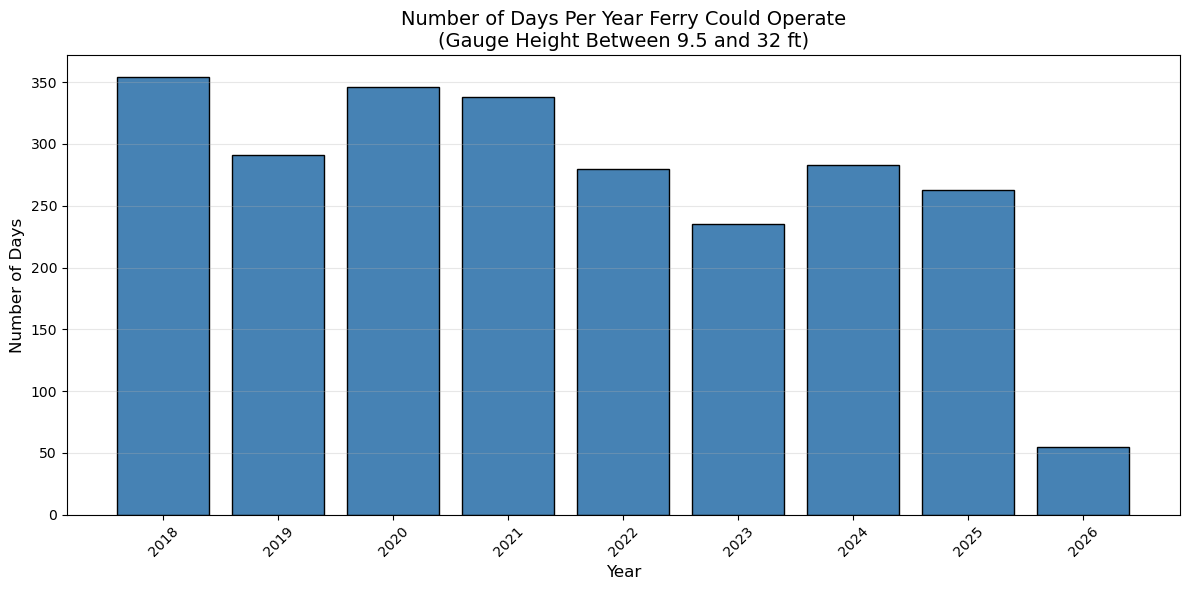

In [195]:
# Filter for daily max gauge values between 9.5 and 32 (inclusive)
daily_max_df['gauge'] = pd.to_numeric(daily_max_df['max_daily_gauge'], errors='coerce')
df_ferry_operable = daily_max_df[daily_max_df['gauge'].between(9.5, 32)].copy()

# Add year column
df_ferry_operable['year'] = pd.to_datetime(df_ferry_operable['date']).dt.year

# Count days per year where ferry could operate
ferry_days_by_year = df_ferry_operable.groupby('year').size().reset_index(name='days_operable')

# Add column for percent of year operational

percent_ferry_op_per_year = (ferry_days_by_year['days_operable'] / 365) * 100
df_ferry_operable['percent'] = (ferry_days_by_year['days_operable'] / 365) * 100
#percent_ferry_op_per_year = df_ferry_operable.groupby('year').size().reset_index(name='percent_operable')


# Calculate percentages
total = ferry_days_by_year['days_operable'].sum()
df_ferry_operable['Percentage'] = (ferry_days_by_year['days_operable'] / total) * 100

# Plot the bar chart
print("Number of day per year where ferry could operate (gauge between 9.5 and 32 ft):")
print(ferry_days_by_year)
print("Percent of year where ferry could operate (gauge between 9.5 and 32 ft):")
print(percent_ferry_op_per_year)

# Create a bar plot
plt.figure(figsize=(12, 6))
plt.bar(ferry_days_by_year['year'], ferry_days_by_year['days_operable'], color='steelblue', edgecolor='black')
plt.title('Number of Days Per Year Ferry Could Operate\n(Gauge Height Between 9.5 and 32 ft)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Days', fontsize=12)
plt.xticks(ferry_days_by_year['year'], rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [196]:
# make sure we have the daily‑max dataframe available
if 'daily_max_df' not in globals():
    daily_max_df = (
        df.groupby(df['datetime'].dt.date)['gauge']
          .max()
          .reset_index()
    )
    daily_max_df.columns = ['date', 'max_daily_gauge']
    daily_max_df['year'] = pd.to_datetime(daily_max_df['date']).dt.year

# mask for days with max gauge between 9.5 and 32 (inclusive)
mask = daily_max_df['max_daily_gauge'].between(9.5, 32)

# count by year
counts_by_year = (
    daily_max_df[mask]
    .groupby('year')
    .size()
    .reset_index(name='days_between')
)

print(counts_by_year)

# simple bar chart
plt.figure(figsize=(10, 5))
plt.bar(counts_by_year['year'], counts_by_year['days_between'],
        color='steelblue', edgecolor='black')
plt.title('Days per Year with Daily Max Gauge between 9.5 and 32 ft')
plt.xlabel('Year')
plt.ylabel('Number of Days')
plt.xticks(counts_by_year['year'], rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

KeyError: 'year'

In [ ]:

# Count days where the daily max gauge is between 9.5 and 32 (inclusive)

# find appropriate column or build daily_max_df if missing
if 'daily_max_df' in globals() and isinstance(daily_max_df, pd.DataFrame):
    ddf = daily_max_df.copy()
else:
    ddf = df.groupby(df['datetime'].dt.date)['gage'].max().reset_index()
    ddf.columns = ['date', 'max_daily_gage']

# choose existing gauge column name
for col in ['guage', 'gage', 'max_daily_gage']:
    if col in ddf.columns:
        gauge_col = col
        break
else:
    raise KeyError("No gauge column found in daily_max_df or df.")

# ensure numeric and count
ddf[gauge_col] = pd.to_numeric(ddf[gauge_col], errors='coerce')
count = int(ddf[gauge_col].between(9.5, 32).sum())
print(count)

In [ ]:
# compute daily minimum gauge and then count days < 9.5 ft by year

# make sure 'gage' is numeric
df['gage'] = pd.to_numeric(df['gage'], errors='coerce')

# daily minimum
daily_min_df = (
    df.groupby(df['datetime'].dt.date)['gage']
      .min()
      .reset_index()
      .rename(columns={'datetime':'date', 'gage':'min_daily_gage'})
)

# add year column
daily_min_df['year'] = pd.to_datetime(daily_min_df['date']).dt.year

# filter and count
min_below = daily_min_df[daily_min_df['min_daily_gage'] < 9.5]
count_by_year = min_below.groupby('year').size().reset_index(name='days_below_9_5')

print(count_by_year)

# simple bar plot
plt.figure(figsize=(10,5))
plt.bar(count_by_year['year'], count_by_year['days_below_9_5'],
        color='steelblue', edgecolor='black')
plt.title('Number of Days Per Year with Daily Min Gauge < 9.5 ft')
plt.xlabel('Year')
plt.ylabel('Days with min < 9.5 ft')
plt.xticks(count_by_year['year'], rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# compute daily maximum gauge and then count days > 35 ft by year

# make sure the gauge column is numeric
df['gage'] = pd.to_numeric(df['gage'], errors='coerce')

# build (or rebuild) the daily‑max dataframe
daily_max_df = df.groupby(df['datetime'].dt.date)['gage'].max().reset_index()
daily_max_df.columns = ['date', 'max_daily_gage']
daily_max_df['year'] = pd.to_datetime(daily_max_df['date']).dt.year

# filter and count
days_over_35 = daily_max_df[daily_max_df['max_daily_gage'] > 35]
count_by_year = days_over_35.groupby('year').size().reset_index(name='days_over_35')
print(count_by_year)

# plot the result
plt.figure(figsize=(10,5))
plt.bar(count_by_year['year'], count_by_year['days_over_35'],
    color='steelblue', edgecolor='black')
plt.title('Number of Days Per Year with Daily Max Gauge > 35 ft')
plt.xlabel('Year')
plt.ylabel('Days > 35 ft')
plt.xticks(count_by_year['year'], rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


Box Plot of Guage by year.

In [ ]:
# Ensure the 'gage' column in df is numeric
df['gage'] = pd.to_numeric(df['gage'], errors='coerce')

# Ensure the 'gage' column in df2 is numeric
df2['gage'] = pd.to_numeric(df2['gage'], errors='coerce')

# Create a DataFrame of the maximum gauge value for each day
daily_max_df = df.groupby(df['datetime'].dt.date)['gage'].max().reset_index()
daily_max_df.columns = ['date', 'max_daily_gage']

# Add a month column to the daily_max_df
daily_max_df['year'] = pd.to_datetime(daily_max_df['date']).dt.year

# Apply vertical offset in feet (convert gage to elevation):
offset_ft = 409.35
daily_max_df['max_daily_elev_ft'] = daily_max_df['max_daily_gage'] + offset_ft

# Group the maximum daily elevation by month
grouped_daily_max = daily_max_df.groupby('year')['max_daily_elev_ft']

# Create a boxplot of the maximum daily elevations grouped by month
plt.figure(figsize=(10, 6))
plt.boxplot(
    [group for _, group in grouped_daily_max],
    labels=grouped_daily_max.groups.keys(),
    flierprops={
        'marker': 'x',  # Outlier marker symbol
        'markerfacecolor': 'red',  # Outlier marker color
        'markeredgecolor': 'black',  # Outlier marker edge color
        'markersize': 3,  # Outlier marker size
        'alpha': 0.5  # Outlier opacity
    }
)
plt.title('Boxplot of Maximum Daily Elevation (gage + 409.35 ft) Grouped by Year')
plt.xlabel('Year')
plt.ylabel('Elevation (ft)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
print(daily_max_df)

Filter Out Events over bottom bridge heights

In [ ]:
# Ensure elevation column exists, then filter for >= 477 ft the 500 year flood level
if 'max_daily_elev_ft' not in daily_max_df.columns:
    daily_max_df['max_daily_elev_ft'] = daily_max_df['max_daily_gage'] + offset_ft

df_477 = daily_max_df[daily_max_df['max_daily_elev_ft'] >= 477].reset_index(drop=True)

# Check if there is any data to display
if df_477.empty:
    print("No data available: Water elevation never reached 477 feet (the 500 year flood level) in this dataset.")
else:
    # Sort by date to ensure proper sequence detection
    df_477_sorted = df_477.sort_values('date').reset_index(drop=True)

    # Calculate the difference between consecutive dates
    df_477_sorted['date_diff'] = df_477_sorted['date'].diff().dt.days

    # Identify event breaks (where date difference > 1 day)
    df_477_sorted['event_id'] = (df_477_sorted['date_diff'] > 1).cumsum()

    # Count events and days per event
    event_summary_477 = df_477_sorted.groupby('event_id').agg(
        event_start=('date', 'min'),
        event_end=('date', 'max'),
        num_days=('date', 'count'),
        max_elevation=('max_daily_elev_ft', 'max')
    ).reset_index(drop=True)

    # Renumber events starting from 1
    event_summary_477.insert(0, 'event_num', range(1, len(event_summary_477) + 1))

    print(f"Total number of events where water levels is above 477 feet (the 500 year flood mark): {len(event_summary_477)}")
    print(f"\n{event_summary_477}")

    # add a year column so we can group by it
    event_summary_by_year_477 = event_summary_477.copy()
    event_summary_by_year_477['year'] = pd.to_datetime(event_summary_by_year_477['event_start']).dt.year

    # group the event durations by year and make a boxplot
    grouped_year = event_summary_by_year_477.groupby('year')['num_days']

    plt.figure(figsize=(10, 6))
    plt.boxplot(
        [grp for _, grp in grouped_year],
        labels=grouped_year.groups.keys(),
        flierprops={'marker': 'x', 'markerfacecolor': 'red',
                    'markeredgecolor': 'black', 'markersize': 3, 'alpha': 0.5}
    )
    plt.title('Boxplot of Event Duration (number of days per event) by Year')
    plt.xlabel('Year')
    plt.ylabel('Number of Days per Event')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
# Ensure elevation column exists, then filter for between 470 ft and 477 feet the 100 year flood level
if 'max_daily_elev_ft' not in daily_max_df.columns:
    daily_max_df['max_daily_elev_ft'] = daily_max_df['max_daily_gage'] + offset_ft

df_470 = daily_max_df[daily_max_df['max_daily_elev_ft'].between(470,477)].reset_index(drop=True)

# Check if there is any data to display
if df_470.empty:
    print("No data available: Water elevation never reached between 470 and 477 feet in this dataset.")
else:
    # Sort by date to ensure proper sequence detection
    df_470_sorted = df_470.sort_values('date').reset_index(drop=True)

    # Calculate the difference between consecutive dates
    df_470_sorted['date_diff'] = df_470_sorted['date'].diff().dt.days

    # Identify event breaks (where date difference > 1 day)
    df_470_sorted['event_id'] = (df_470_sorted['date_diff'] > 1).cumsum()

    # Count events and days per event
    event_summary_470 = df_470_sorted.groupby('event_id').agg(
        event_start=('date', 'min'),
        event_end=('date', 'max'),
        num_days=('date', 'count'),
        max_elevation=('max_daily_elev_ft', 'max')
    ).reset_index(drop=True)

    # Renumber events starting from 1
    event_summary_470.insert(0, 'event_num', range(1, len(event_summary_470) + 1))

    print(f"Total number of events where water levels is between 470 feet and 477 feet: {len(event_summary_470)}")
    print(f"\n{event_summary_470}")

    # add a year column so we can group by it
    event_summary_by_year_470 = event_summary_470.copy()
    event_summary_by_year_470['year'] = pd.to_datetime(event_summary_by_year_470['event_start']).dt.year

    # group the event durations by year and make a boxplot
    grouped_year = event_summary_by_year_470.groupby('year')['num_days']

    plt.figure(figsize=(10, 6))
    plt.boxplot(
        [grp for _, grp in grouped_year],
        labels=grouped_year.groups.keys(),
        flierprops={'marker': 'x', 'markerfacecolor': 'red',
                    'markeredgecolor': 'black', 'markersize': 3, 'alpha': 0.5}
    )
    plt.title('Boxplot of Event Duration (number of days per event) by Year')
    plt.xlabel('Year')
    plt.ylabel('Number of Days per Event')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
# Ensure elevation column exists, then filter for between 450 ft and 470 feet the 100 year flood level
if 'max_daily_elev_ft' not in daily_max_df.columns:
    daily_max_df['max_daily_elev_ft'] = daily_max_df['max_daily_gage'] + offset_ft

df_450 = daily_max_df[daily_max_df['max_daily_elev_ft'].between(450,470)].reset_index(drop=True)


# Sort by date to ensure proper sequence detection
df_450_sorted = df_450.sort_values('date').reset_index(drop=True)

# Calculate the difference between consecutive dates
df_450_sorted['date_diff'] = df_450_sorted['date'].diff().dt.days

# Identify event breaks (where date difference > 1 day)
df_450_sorted['event_id'] = (df_450_sorted['date_diff'] > 1).cumsum()

# Count events and days per event
event_summary_450 = df_450_sorted.groupby('event_id').agg(
    event_start=('date', 'min'),
    event_end=('date', 'max'),
    num_days=('date', 'count'),
    max_elevation=('max_daily_elev_ft', 'max')
).reset_index(drop=True)

# Renumber events starting from 1
event_summary_450.insert(0, 'event_num', range(1, len(event_summary_450) + 1))

print(f"Total number of events where water levels is between 450 feet and 470 feet (the 100 year flood mark): {len(event_summary_450)}")
print(f"\n{event_summary_450}")

# add a year column so we can group by it
event_summary_by_year_450 = event_summary_450.copy()
event_summary_by_year_450['year'] = pd.to_datetime(event_summary_by_year_450['event_start']).dt.year

# group the event durations by year and make a boxplot
grouped_year = event_summary_by_year_450.groupby('year')['num_days']

plt.figure(figsize=(10, 6))
plt.boxplot(
    [grp for _, grp in grouped_year],
    labels=grouped_year.groups.keys(),
    flierprops={'marker': 'x', 'markerfacecolor': 'red',
                'markeredgecolor': 'black', 'markersize': 3, 'alpha': 0.5}
)
plt.title('Boxplot of Event Duration (number of days per event) by Year where water levels is between 450 feet and 470 feet')
plt.xlabel('Year')
plt.ylabel('Number of Days per Event')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Count days per year with daily max elevation between 450 and 470 ft and plot a simple bar chart

# use existing df_450 if available, otherwise build it from daily_max_df
if 'df_450' in globals() and isinstance(df_450, pd.DataFrame):
    df_days = df_450.copy()
else:
    if 'daily_max_df' not in globals():
        daily_max_df = df.groupby(df['datetime'].dt.date)['gage'].max().reset_index()
        daily_max_df.columns = ['date', 'max_daily_gage']
        daily_max_df['max_daily_elev_ft'] = pd.to_numeric(daily_max_df['max_daily_gage'], errors='coerce') + offset_ft
    else:
        if 'max_daily_elev_ft' not in daily_max_df.columns:
            daily_max_df['max_daily_elev_ft'] = pd.to_numeric(daily_max_df['max_daily_gage'], errors='coerce') + offset_ft
    df_days = daily_max_df[daily_max_df['max_daily_elev_ft'].between(450, 470)].copy()

# ensure year column and compute counts
df_days['year'] = pd.to_datetime(df_days['date']).dt.year
counts_450_470 = df_days.groupby('year').size().reset_index(name='days_450_470')

# plot
plt.figure(figsize=(10,5))
plt.bar(counts_450_470['year'], counts_450_470['days_450_470'], color='steelblue', edgecolor='black')
plt.title('Number of Days per Year with Daily Max Elevation Between 450 ft and 470 ft')
plt.xlabel('Year')
plt.ylabel('Number of Days')
plt.xticks(counts_450_470['year'], rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# print counts
print(counts_450_470)

In [ ]:
# Ensure elevation column exists, then filter for between 435 ft and 450 feet the 100 year flood level
if 'max_daily_elev_ft' not in daily_max_df.columns:
    daily_max_df['max_daily_elev_ft'] = daily_max_df['max_daily_gage'] + offset_ft

df_435 = daily_max_df[daily_max_df['max_daily_elev_ft'].between(435,450)].reset_index(drop=True)


# Sort by date to ensure proper sequence detection
df_435_sorted = df_435.sort_values('date').reset_index(drop=True)

# Calculate the difference between consecutive dates
df_435_sorted['date_diff'] = df_435_sorted['date'].diff().dt.days

# Identify event breaks (where date difference > 1 day)
df_435_sorted['event_id'] = (df_435_sorted['date_diff'] > 1).cumsum()

# Count events and days per event
event_summary_435 = df_435_sorted.groupby('event_id').agg(
    event_start=('date', 'min'),
    event_end=('date', 'max'),
    num_days=('date', 'count'),
    max_elevation=('max_daily_elev_ft', 'max')
).reset_index(drop=True)

# Renumber events starting from 1
event_summary_435.insert(0, 'event_num', range(1, len(event_summary_435) + 1))

print(f"Total number of events where water levels is between 435 feet and 450 feet (below the 100 year flood mark): {len(event_summary_435)}")
print(f"\n{event_summary_435}")

# add a year column so we can group by it
event_summary_by_year_435 = event_summary_435.copy()
event_summary_by_year_435['year'] = pd.to_datetime(event_summary_by_year_435['event_start']).dt.year

# group the event durations by year and make a boxplot
grouped_year = event_summary_by_year_435.groupby('year')['num_days']

plt.figure(figsize=(10, 6))
plt.boxplot(
    [grp for _, grp in grouped_year],
    labels=grouped_year.groups.keys(),
    flierprops={'marker': 'x', 'markerfacecolor': 'red',
                'markeredgecolor': 'black', 'markersize': 3, 'alpha': 0.5}
)
plt.title('Boxplot of Event Duration (number of days per event) by Year where water levels is between 435 feet and 450 feet')
plt.xlabel('Year')
plt.ylabel('Number of Days per Event')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Count days per year with daily max elevation between 435 and 450 ft and plot a simple bar chart

# use existing df_450 if available, otherwise build it from daily_max_df
if 'df_435' in globals() and isinstance(df_435, pd.DataFrame):
    df_days = df_435.copy()
else:
    if 'daily_max_df' not in globals():
        daily_max_df = df.groupby(df['datetime'].dt.date)['gage'].max().reset_index()
        daily_max_df.columns = ['date', 'max_daily_gage']
        daily_max_df['max_daily_elev_ft'] = pd.to_numeric(daily_max_df['max_daily_gage'], errors='coerce') + offset_ft
    else:
        if 'max_daily_elev_ft' not in daily_max_df.columns:
            daily_max_df['max_daily_elev_ft'] = pd.to_numeric(daily_max_df['max_daily_gage'], errors='coerce') + offset_ft
    df_days = daily_max_df[daily_max_df['max_daily_elev_ft'].between(435, 450)].copy()

# ensure year column and compute counts
df_days['year'] = pd.to_datetime(df_days['date']).dt.year
counts_435_450 = df_days.groupby('year').size().reset_index(name='days_435_450')

# plot
plt.figure(figsize=(10,5))
plt.bar(counts_435_450['year'], counts_435_450['days_435_450'], color='steelblue', edgecolor='black')
plt.title('Number of Days per Year with Daily Max Elevation Between 435 ft and 450 ft')
plt.xlabel('Year')
plt.ylabel('Number of Days')
plt.xticks(counts_435_450['year'], rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# print counts
print(counts_435_450)

Evalulate the number of flood events with the lenght of the event and max river height durring event.

In [ ]:
# Box plot of days were river was above 441 ft, the elevation where gauge is 35 feet.
# Ensure elevation column exists, then filter for >= 441 feet
if 'max_daily_elev_ft' not in daily_max_df.columns:
    daily_max_df['max_daily_elev_ft'] = daily_max_df['max_daily_gage'] + offset_ft

df_441 = daily_max_df[daily_max_df['max_daily_elev_ft']>= 441].reset_index(drop=True)

# Check if there is any data to display
if df_441.empty:
    print("No data available: Water elevation never reached 441 feet in this dataset.")
else:
    # Sort by date to ensure proper sequence detection
    df_441_sorted = df_441.sort_values('date').reset_index(drop=True)

    # Calculate the difference between consecutive dates
    df_441_sorted['date_diff'] = df_441_sorted['date'].diff().dt.days

    # Identify event breaks (where date difference > 1 day)
    df_441_sorted['event_id'] = (df_441_sorted['date_diff'] > 1).cumsum()

    # Count events and days per event
    event_summary_441 = df_441_sorted.groupby('event_id').agg(
        event_start=('date', 'min'),
        event_end=('date', 'max'),
        num_days=('date', 'count'),
        max_elevation=('max_daily_elev_ft', 'max')
    ).reset_index(drop=True)

    # Renumber events starting from 1
    event_summary_441.insert(0, 'event_num', range(1, len(event_summary_441) + 1))

    print(f"Total number of events where water levels is above 441 feet: {len(event_summary_441)}")
    print(f"\n{event_summary_441}")

    # add a year column so we can group by it
    event_summary_by_year_441 = event_summary_441.copy()
    event_summary_by_year_441['year'] = pd.to_datetime(event_summary_by_year_441['event_start']).dt.year

    # group the event durations by year and make a boxplot
    grouped_year = event_summary_by_year_441.groupby('year')['num_days']

    plt.figure(figsize=(10, 6))
    plt.boxplot(
        [grp for _, grp in grouped_year],
        labels=grouped_year.groups.keys(),
        flierprops={'marker': 'x', 'markerfacecolor': 'red',
                    'markeredgecolor': 'black', 'markersize': 3, 'alpha': 0.5}
    )
    plt.title('Boxplot of Event Duration (number of days per event) by Year where water levels are above 441 feet (35 feet guage)')
    plt.xlabel('Year')
    plt.ylabel('Number of Days per Event')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
# Count days per year with daily max gauge >= 32 ft and plot a simple bar chart

# Ensure daily_max_df exists with the gauge column
if 'daily_max_df' not in globals():
    daily_max_df = df.groupby(df['datetime'].dt.date)['gage'].max().reset_index()
    daily_max_df.columns = ['date', 'max_daily_gage']

# Filter for max_daily_gage >= 32
df_gage_32 = daily_max_df[daily_max_df['max_daily_gage'] >= 32].copy()

# Add year column and compute counts
df_gage_32['year'] = pd.to_datetime(df_gage_32['date']).dt.year
counts_gage_32 = df_gage_32.groupby('year').size().reset_index(name='days_gage_32')

# Plot
plt.figure(figsize=(10, 5))
plt.bar(counts_gage_32['year'], counts_gage_32['days_gage_32'], color='steelblue', edgecolor='black')
plt.title('Number of Days per Year with Daily Max Gauge >= 32 ft')
plt.xlabel('Year')
plt.ylabel('Number of Days')
plt.xticks(counts_gage_32['year'], rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Print counts
print(counts_gage_32)

In [ ]:
# Create a simple bar chart of the number of days per year where daily max elevation >= 441 ft
days_per_year_441 = event_summary_by_year_441.groupby('year')['num_days'].sum().reset_index()
days_per_year_441.columns = ['year', 'total_days']

plt.figure(figsize=(12, 6))
plt.bar(days_per_year_441['year'], days_per_year_441['total_days'], color='steelblue', edgecolor='black')
plt.title('Total Number of Days Per Year Where Elevation >= 441 ft', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Days', fontsize=12)
plt.xticks(days_per_year_441['year'], rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Create a simple bar chart of the number of days per year where daily max elevation <= 418 ft
days_per_year_418 = daily_max_df[daily_max_df['max_daily_elev_ft'] <= 418].copy()
days_per_year_418['year'] = pd.to_datetime(days_per_year_418['date']).dt.year
days_count_418 = days_per_year_418.groupby('year').size().reset_index(name='total_days')

plt.figure(figsize=(12, 6))
plt.bar(days_count_418['year'], days_count_418['total_days'], color='steelblue', edgecolor='black')
plt.title('Total Number of Days Per Year Where Elevation less than or equal to 418 ft (9.5 feet guage)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Days', fontsize=12)
plt.xticks(days_count_418['year'], rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()